In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import torch
import gpytorch

from l4acados.models.pytorch_models.gpytorch_models.gpytorch_gp import (
    BatchIndependentMultitaskGPModel,
    BatchIndependentInducingPointGpModel,
)
from l4acados.models import (
    PyTorchFeatureSelector,
    GPyTorchResidualModel,
)

from train_gp_hyperparams import train_gp_model

In [2]:
WORKDIR = "/home/amon/Repositories/crs-2.0-gpmpc/src/ros4crs/rospy_controllers"
x_data_path = os.path.join(WORKDIR, "data", "x_data.csv")
y_data_path = os.path.join(WORKDIR, "data", "y_data.csv")

In [3]:
def load_tensor_data(x_data_path: str, y_data_path: str):
    try:
        with open(x_data_path, "r") as file:
            train_x_tensor = torch.from_numpy(np.genfromtxt(file, delimiter=",")).type(
                torch.float32
            )
    except FileNotFoundError:
        print(f"File {x_data_path} does not exist.")
    except Exception as e:
        raise e

    # If the data only has one feature, we need to add a batch dimension
    if train_x_tensor.dim() == 1:
        train_x_tensor = torch.unsqueeze(train_x_tensor, -1)

    try:
        with open(y_data_path, "r") as file:
            train_y_tensor = torch.from_numpy(np.genfromtxt(file, delimiter=",")).type(
                torch.float32
            )
    except FileNotFoundError:
        print(f"File {y_data_path} does not exist.")
    except Exception as e:
        raise e

    # If the data only has one feature, we need to add a batch dimension
    if train_y_tensor.dim() == 1:
        train_y_tensor = torch.unsqueeze(train_y_tensor, -1)

    return train_x_tensor, train_y_tensor

In [4]:
x_train_data, y_train_data = load_tensor_data(x_data_path, y_data_path)

In [5]:
x_train_data.shape, y_train_data.shape

(torch.Size([950, 12]), torch.Size([950, 3]))

In [6]:
input_selection = [0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0]
input_feature_selector = PyTorchFeatureSelector(input_selection)

gpytorch_gp_model = BatchIndependentMultitaskGPModel(
    train_x=input_feature_selector(x_train_data),
    train_y=y_train_data,
    likelihood=gpytorch.likelihoods.MultitaskGaussianLikelihood(
        num_tasks=3,
    ),
    residual_dimension=3,
    input_dimension=sum(input_selection),
    use_ard=True,
)
hyperparameter_names_dict = {
    "likelihood.task_noises": "likelihood.task_noises",
    "kernel.lengthscale": "covar_module.base_kernel.lengthscale",
    "kernel.outputscale": "covar_module.outputscale",
}

train_gp_params = True

if train_gp_params:
    gpytorch_gp_model, likelihood = train_gp_model(
        gpytorch_gp_model,
        torch_seed=5678,
        training_iterations=300,
        learning_rate=0.1,
    )
else:
    likelihood_task_noise = torch.Tensor([0.0001, 0.0001, 0.0783])
    kernel_lengthscale = torch.Tensor(
        [  #  vx      vy      dyaw    T       steer
            [[13.1498, 16.3301, 15.1622, 7.5505, 16.8039]],
            [[15.0484, 15.6341, 13.2193, 14.2469, 7.6535]],
            [[15.5188, 16.2151, 9.1628, 14.2396, 7.5373]],
        ]
    )
    kernel_outputscale = torch.Tensor([0.0598, 0.0596, 0.1997])
    hyperparams_dict = {
        "likelihood.task_noises": likelihood_task_noise,
        "kernel.lengthscale": kernel_lengthscale,
        "kernel.outputscale": kernel_outputscale,
    }

    gpytorch_gp_model.train()
    gpytorch_gp_model.initialize(
        **{
            hyperparameter_names_dict[key]: hyperparams_dict[key]
            for key in hyperparameter_names_dict.keys()
        }
    )
gpytorch_gp_model.eval()

Training params: [('likelihood.raw_task_noises', Parameter containing:
tensor([0., 0., 0.], requires_grad=True)), ('likelihood.raw_noise', Parameter containing:
tensor([0.], requires_grad=True)), ('covar_module.raw_outputscale', Parameter containing:
tensor([0., 0., 0.], requires_grad=True)), ('covar_module.base_kernel.raw_lengthscale', Parameter containing:
tensor([[[0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0.]]], requires_grad=True))]
Iter 1/300 - Loss: 1.489
Iter 21/300 - Loss: 0.683
Iter 41/300 - Loss: -0.157
Iter 61/300 - Loss: -0.757
Iter 81/300 - Loss: -1.273
Iter 101/300 - Loss: -1.284
Iter 121/300 - Loss: -0.909
Iter 141/300 - Loss: -0.860
Iter 161/300 - Loss: -0.930
Iter 181/300 - Loss: -0.918
Iter 201/300 - Loss: -0.897
Iter 221/300 - Loss: -0.964
Iter 241/300 - Loss: -0.962
Iter 261/300 - Loss: -0.962
Iter 281/300 - Loss: -0.868


BatchIndependentMultitaskGPModel(
  (likelihood): MultitaskGaussianLikelihood(
    (raw_task_noises_constraint): GreaterThan(1.000E-04)
    (raw_noise_constraint): GreaterThan(1.000E-04)
  )
  (mean_module): ZeroMean()
  (covar_module): ScaleKernel(
    (base_kernel): RBFKernel(
      (raw_lengthscale_constraint): Positive()
    )
    (raw_outputscale_constraint): Positive()
  )
)

In [7]:
# print optimized hyperparameters
gpytorch_gp_model.state_dict()

OrderedDict([('likelihood.raw_task_noises',
              tensor([-12.2042, -12.2464,  -8.4953])),
             ('likelihood.raw_noise', tensor([-12.1870])),
             ('likelihood.raw_task_noises_constraint.lower_bound',
              tensor(1.0000e-04)),
             ('likelihood.raw_task_noises_constraint.upper_bound',
              tensor(inf)),
             ('likelihood.raw_noise_constraint.lower_bound',
              tensor(1.0000e-04)),
             ('likelihood.raw_noise_constraint.upper_bound', tensor(inf)),
             ('covar_module.raw_outputscale',
              tensor([-3.7660, -6.7368,  4.0361])),
             ('covar_module.base_kernel.raw_lengthscale',
              tensor([[[ 3.8532,  0.2237,  7.8679,  1.9716,  0.6846]],
              
                      [[ 9.2523, -0.5604, 13.1703,  8.9179, -1.1526]],
              
                      [[ 0.5589, -4.4976,  1.4823, -3.5956, -1.9027]]])),
             ('covar_module.base_kernel.raw_lengthscale_constraint.lower

/home/amon/.pyenv/versions/3.9.13/envs/l4acados_dev/lib/python3.9/site-packages/gpytorch/models/exact_gp.py:310: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(


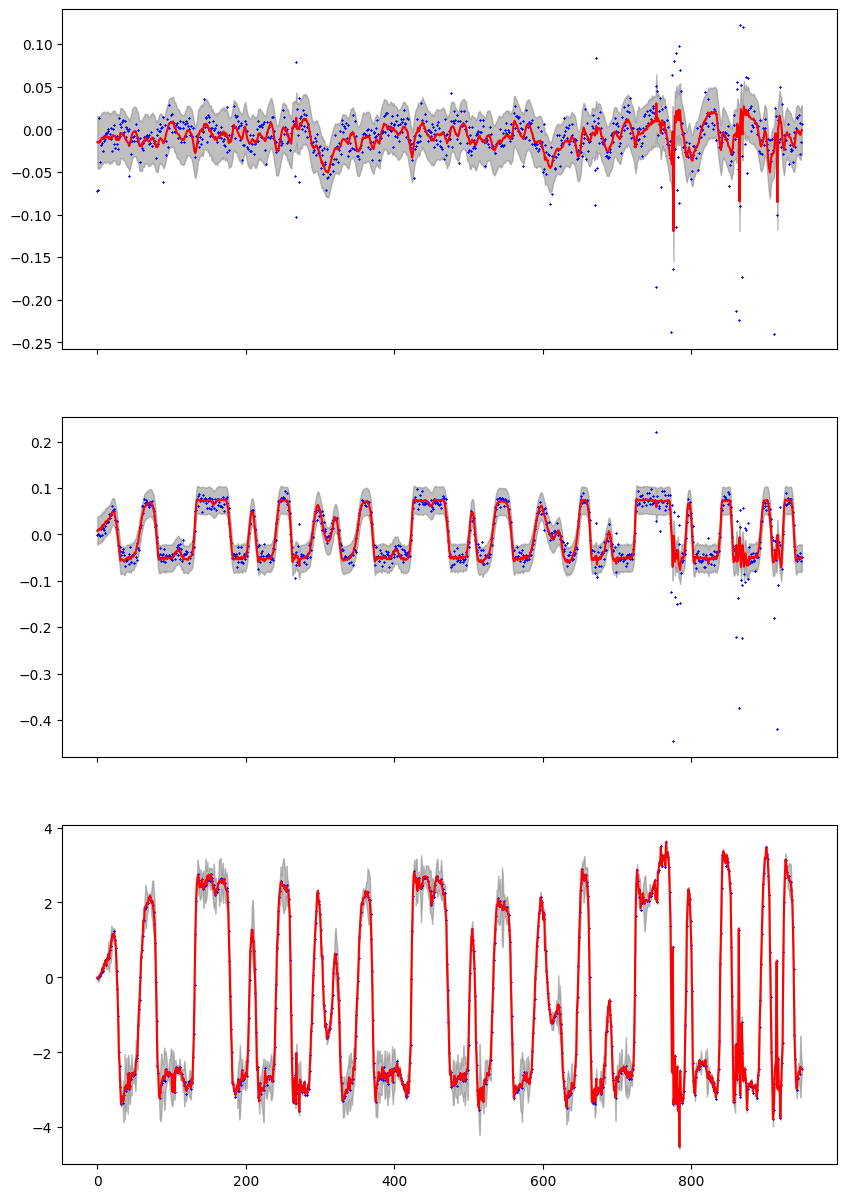

In [9]:
fig, axs = plt.subplots(
    y_train_data.shape[1], 1, figsize=(10, 5 * y_train_data.shape[1]), sharex=True
)

for i, ax in enumerate(axs):
    with torch.no_grad():
        output = likelihood(gpytorch_gp_model(input_feature_selector(x_train_data)))
        mean = output.mean
        lower, upper = output.confidence_region()

    ax.plot(
        y_train_data.numpy()[:, i],
        "x",
        color="blue",
        label="Training Data",
        markersize=1,
    )
    ax.plot(mean.numpy()[:, i], "r", label="GP Mean")
    ax.fill_between(
        np.arange(len(mean)),
        lower.numpy()[:, i],
        upper.numpy()[:, i],
        color="gray",
        alpha=0.5,
    )